# Data Exploration & Modeling

## Setup: Imports

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    silhouette_score, silhouette_samples
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBRegressor, XGBClassifier

%matplotlib inline
plt.style.use('default')

## 1. Aggregate

In [3]:
data_folder = 'data/raw/'

# Load
files = glob.glob(data_folder + '*.csv')
print(f'Found {len(files)} files')

# Combine
dfs = [pd.read_csv(f) for f in files]
data = pd.concat(dfs, ignore_index=True)
print(f'Combined shape: {data.shape}')

data.to_csv('data/processed/data_aggregated.csv', index=False)

Found 1 files
Combined shape: (2584, 20)


## 2. Browse

Load and inspect raw data.

In [102]:
# Select input file
INPUT_FILE = 'data/raw/seismic.csv'
TARGET_COLUMN = None # column name or None
TIME_COLUMN = None   # column name for time axis, or None

df = pd.read_csv(INPUT_FILE)
print(f'Loaded: {INPUT_FILE}')
print(f'Shape: {df.shape}')

Loaded: data/raw/seismic.csv
Shape: (2584, 19)


In [64]:
# Column info
print('\nColumn Types:')
for col in df.columns:
    print(f'  {col:30s} {str(df[col].dtype):15s} unique: {df[col].nunique()}')


Column Types:
  seismic                        str             unique: 2
  seismoacoustic                 str             unique: 3
  shift                          str             unique: 2
  genergy                        int64           unique: 2212
  gpuls                          int64           unique: 1128
  gdenergy                       int64           unique: 334
  gdpuls                         int64           unique: 292
  ghazard                        str             unique: 3
  nbumps                         int64           unique: 10
  nbumps2                        int64           unique: 7
  nbumps3                        int64           unique: 7
  nbumps4                        int64           unique: 4
  nbumps5                        int64           unique: 2
  nbumps6                        int64           unique: 1
  nbumps7                        int64           unique: 1
  nbumps89                       int64           unique: 1
  energy                      

In [9]:
# Nulls
print('\nMissing Values:')
for col in df.columns:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        pct = 100 * n_null / len(df)
        print(f'  {col:30s} {n_null:6d} ({pct:5.1f}%)')


Missing Values:


In [10]:
# Sample data
print('\nFirst few rows:')
df.head(10)


First few rows:


,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,a,a,N,15180,48,-72,-72,a,0,0,0,0,0,0,0,0,0,0,0
1,a,a,N,14720,33,-70,-79,a,1,0,1,0,0,0,0,0,2000,2000,0
2,a,a,N,8050,30,-81,-78,a,0,0,0,0,0,0,0,0,0,0,0
3,a,a,N,28820,171,-23,40,a,1,0,1,0,0,0,0,0,3000,3000,0
4,a,a,N,12640,57,-63,-52,a,0,0,0,0,0,0,0,0,0,0,0
5,a,a,W,63760,195,-73,-65,a,0,0,0,0,0,0,0,0,0,0,0
6,a,a,W,207930,614,-6,18,a,2,2,0,0,0,0,0,0,1000,700,0
7,a,a,N,48990,194,-27,-3,a,1,0,1,0,0,0,0,0,4000,4000,0
8,a,a,N,100190,303,54,52,a,0,0,0,0,0,0,0,0,0,0,0
9,a,a,W,247620,675,4,25,a,1,1,0,0,0,0,0,0,500,500,0


## 3. EDA: Metrics

In [16]:
# Descriptive statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seismic,2584,2,a,1682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seismoacoustic,2584,3,a,1580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,2584,2,W,1663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genergy,2584.0,NaN,NaN,NaN,90242.52322,229200.508894,100.0,11660.0,25485.0,52832.5,2595650.0
gpuls,2584.0,NaN,NaN,NaN,538.579334,562.652536,2.0,190.0,379.0,669.0,4518.0
gdenergy,2584.0,NaN,NaN,NaN,12.375774,80.319051,-96.0,-37.0,-6.0,38.0,1245.0
gdpuls,2584.0,NaN,NaN,NaN,4.508901,63.166556,-96.0,-36.0,-6.0,30.25,838.0
ghazard,2584,3,a,2342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nbumps,2584.0,NaN,NaN,NaN,0.85952,1.364616,0.0,0.0,0.0,1.0,9.0
nbumps2,2584.0,NaN,NaN,NaN,0.393576,0.783772,0.0,0.0,0.0,1.0,8.0


In [103]:
numeric_cols = []
categorical_cols = []

for col in df.columns:
    if col == TARGET_COLUMN:
        continue
    
    if df[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
print(f'Categorical features: {len(categorical_cols)}')
print(f'Numeric features: {len(numeric_cols)}')

Categorical features: 4
Numeric features: 15


In [13]:
# Target analysis
if TARGET_COLUMN and TARGET_COLUMN in df.columns:
    print(f'Target: {TARGET_COLUMN}')
    print(f'Type: {df[TARGET_COLUMN].dtype}')

    if df[TARGET_COLUMN].dtype in ['int64', 'float64']:
        print(f'Min:    {df[TARGET_COLUMN].min():.6f}')
        print(f'Max:    {df[TARGET_COLUMN].max():.6f}')
        print(f'Mean:   {df[TARGET_COLUMN].mean():.6f}')
        print(f'Median: {df[TARGET_COLUMN].median():.6f}')
        print(f'Std dev:    {df[TARGET_COLUMN].std():.6f}')
        print(f'Variance:    {df[TARGET_COLUMN].var():.6f}')
    else:
        print(f'Unique: {df[TARGET_COLUMN].nunique()}')
        print(df[TARGET_COLUMN].value_counts())

In [39]:
# Correlations with target
if TARGET_COLUMN and TARGET_COLUMN in df.columns and df[TARGET_COLUMN].dtype in ['int64', 'float64'] and numeric_cols:
    print(f'\nTop correlations with {TARGET_COLUMN}:')
    corrs = []
    for col in numeric_cols:
        c = df[col].corr(df[TARGET_COLUMN])
        corrs.append((col, c))
    
    corrs.sort(key=lambda x: abs(x[1]), reverse=True)
    for col, c in corrs[:10]:
        print(f'  {col:30s} {c:7.4f}')

## 4. EDA: Visualizations

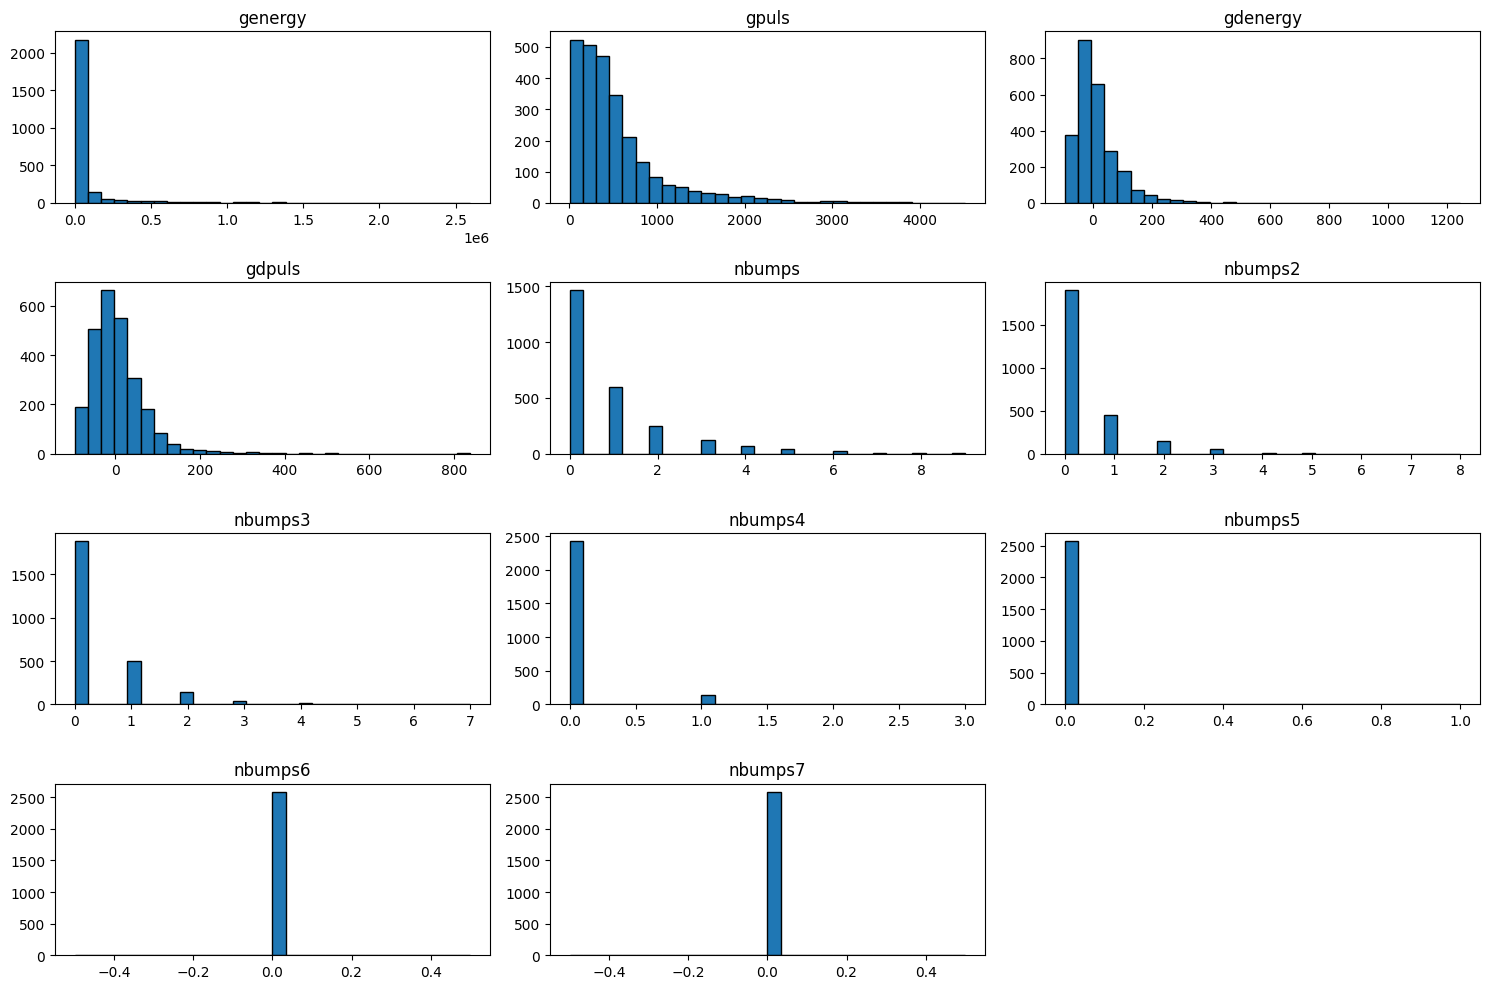

In [43]:
# Histograms of numeric columns
plot_cols = numeric_cols[:11]

# Add target if numeric
if TARGET_COLUMN in df.columns and df[TARGET_COLUMN].dtype in ['int64', 'float64']:
    plot_cols = [TARGET_COLUMN] + plot_cols

if plot_cols:
    n_plots = len(plot_cols)
    fig, axes = plt.subplots(4, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(plot_cols):
        axes[idx].hist(df[col], bins=30, edgecolor='black')
        axes[idx].set_title(col)
    
    # Hide unused
    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    #plt.savefig('data/processed/eda_distributions.png', dpi=100, bbox_inches='tight')

In [65]:
# Category plots
plot_cols = categorical_cols[:11]

# Add target if categorical
if TARGET_COLUMN in df.columns and df[TARGET_COLUMN].dtype == 'object':
    plot_cols = [TARGET_COLUMN] + plot_cols

if plot_cols:
    n_plots = len(plot_cols)
    fig, axes = plt.subplots(4, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(plot_cols):
        df[col].value_counts().head(15).plot(kind='bar', ax=axes[idx], edgecolor='black')
        axes[idx].set_title(col)
        axes[idx].set_xlabel('')
    
    # Hide unused
    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    #plt.savefig('data/processed/eda_categorical_plots.png', dpi=100, bbox_inches='tight')

In [ ]:
# Categorical features vs numeric target
if TARGET_COLUMN and TARGET_COLUMN in df.columns and categorical_cols and df[TARGET_COLUMN].dtype in ['int64', 'float64']:
    n_plots = min(len(categorical_cols), 6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols[:6]):
        df.boxplot(column=TARGET_COLUMN, by=col, ax=axes[idx])
        axes[idx].set_title(f'{TARGET_COLUMN} by {col}')
        axes[idx].set_xlabel(col)
    
    for ax in axes[n_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    #plt.savefig('data/processed/eda_categorical.png', dpi=100, bbox_inches='tight')

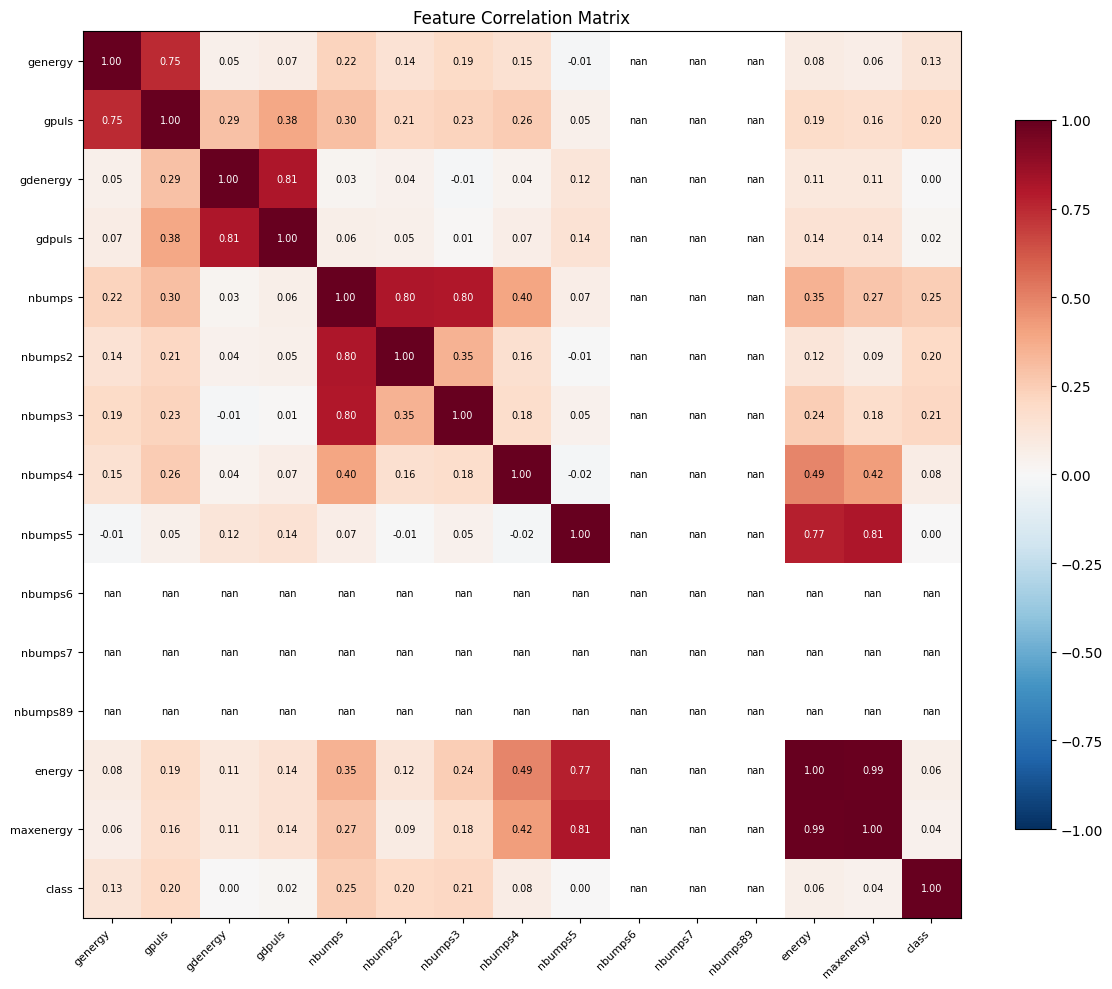

In [28]:
# Correlation heatmap
if numeric_cols:
    corr_matrix = df[numeric_cols].corr()
    n = len(numeric_cols)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(numeric_cols, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Annotate
    if n <= 15:
        for i in range(n):
            for j in range(n):
                val = corr_matrix.values[i, j]
                color = 'white' if abs(val) > 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}',
                        ha='center', va='center', fontsize=7, color=color)

    ax.set_title('Feature Correlation Matrix')
    plt.tight_layout()
    #plt.savefig('data/processed/eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')

## 4b. Time-Series EDA

In [ ]:
# Parse and clean time column
if TIME_COLUMN and TIME_COLUMN in df.columns:
    nat_before = df[TIME_COLUMN].isna().sum()
    df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN], infer_datetime_format=True, errors='coerce')
    nat_after = df[TIME_COLUMN].isna().sum()
    failed = nat_after - nat_before
    if failed > 0:
        print(f'Warning: {failed} rows failed to parse as datetime (coerced to NaT)')

    # Sort by time and reset index
    df = df.sort_values(TIME_COLUMN).reset_index(drop=True)

    t_min = df[TIME_COLUMN].min()
    t_max = df[TIME_COLUMN].max()
    t_span = t_max - t_min
    print(f'Time column: {TIME_COLUMN}')
    print(f'  Range: {t_min}  to  {t_max}')
    print(f'  Span:  {t_span}')
    print(f'  Rows:  {len(df)}')
else:
    print('TIME_COLUMN not set or not found in data — skipping time-series EDA.')

In [ ]:
# Plot all numeric columns vs time
if TIME_COLUMN and TIME_COLUMN in df.columns:
    ts_numeric = [c for c in numeric_cols if c != TIME_COLUMN]

    # If target is numeric, plot it first in its own subplot
    if TARGET_COLUMN and TARGET_COLUMN in df.columns and df[TARGET_COLUMN].dtype in ['int64', 'float64']:
        fig, ax = plt.subplots(figsize=(15, 3))
        ax.plot(df[TIME_COLUMN], df[TARGET_COLUMN], alpha=0.7, linewidth=0.8)
        ax.set_title(f'{TARGET_COLUMN} (target) vs {TIME_COLUMN}')
        ax.set_xlabel(TIME_COLUMN)
        ax.set_ylabel(TARGET_COLUMN)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

    # Plot remaining numeric columns in a grid
    plot_cols_ts = ts_numeric[:11]
    if plot_cols_ts:
        n_plots = len(plot_cols_ts)
        fig, axes = plt.subplots(4, 3, figsize=(15, 12))
        axes = axes.flatten()

        for idx, col in enumerate(plot_cols_ts):
            axes[idx].plot(df[TIME_COLUMN], df[col], alpha=0.5, linewidth=0.6)
            axes[idx].set_title(col)
            axes[idx].set_xlabel(TIME_COLUMN)
            axes[idx].grid(True, alpha=0.3)

        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        #plt.savefig('data/processed/eda_timeseries.png', dpi=100, bbox_inches='tight')
else:
    print('TIME_COLUMN not set — skipping time-series plots.')

## 5. Clean Data (Optional)

Skip this cell if your data doesn't need cleaning.

In [55]:
# Make a copy for cleaning
df_clean = df.copy()
print(f'Input shape: {df_clean.shape}')

# Remove rows where target is null
#df_clean = df_clean[~df_clean[TARGET_COLUMN].isnull()]

# Remove outliers (3-sigma rule)
#for col in numeric_cols:
#   mean = df_clean[col].mean()
#   std = df_clean[col].std()
#   df_clean = df_clean[(df_clean[col] >= mean - 3*std) & (df_clean[col] <= mean + 3*std)]

# Filter impossible values
#df_clean = df_clean[df_clean['energy'] > 0]

# Running average (moving average)
#df_clean['column_ma5'] = df_clean['column'].rolling(window=5).mean()

# Flag outliers using rolling window
#df_clean['column_rolling_std'] = df_clean['column'].rolling(window=10).std()
#df_clean['is_outlier'] = abs(df_clean['column'] - df_clean['column'].rolling(window=10).mean()) > 2 * df_clean['column_rolling_std']
#df_clean = df_clean[~df_clean['is_outlier']]

print(f'Output shape: {df_clean.shape}')

# Use cleaned data
df_raw = df.copy()
df = df_clean

# Rebuild column lists after cleaning
numeric_cols = []
categorical_cols = []
for col in df.columns:
    if col == TARGET_COLUMN:
        continue
    if df[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
print(f'Categorical features: {len(categorical_cols)}')
print(f'Numeric features: {len(numeric_cols)}')

Input shape: (2584, 55)
Output shape: (2584, 55)
Categorical features: 40
Numeric features: 15


## 5b. Encode Categoricals and Regularize Features

Most models require encoding. Exceptions: tree-based methods, language ML

Most models require regularization. Exceptions: tree-based methods, naive Bayes

In [104]:
# Rebuild categorical list from current df (safe on rerun)
categorical_cols = [col for col in df.columns
                    if df[col].dtype not in ['int64', 'float64'] and col != TARGET_COLUMN]

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype='int64')
    print(f'Encoded: {categorical_cols}')

# Get all feature columns (numeric + one-hot encoded), excluding target and time
exclude = {TARGET_COLUMN, TIME_COLUMN}
feature_cols = [col for col in df.columns
                if col not in exclude
                and df[col].dtype in ['int64', 'float64', 'uint8', 'bool']]

print(f'Features after encoding: {len(feature_cols)}')
print(f'Shape: {df.shape}')
df.head(3)

Encoded: ['seismic', 'seismoacoustic', 'shift', 'ghazard']
Features after encoding: 25
Shape: (2584, 25)


,genergy,gpuls,gdenergy,gdpuls,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,...,seismic_a,seismic_b,seismoacoustic_a,seismoacoustic_b,seismoacoustic_c,shift_N,shift_W,ghazard_a,ghazard_b,ghazard_c
0,15180,48,-72,-72,0,0,0,0,0,0,...,1,0,1,0,0,1,0,1,0,0
1,14720,33,-70,-79,1,0,1,0,0,0,...,1,0,1,0,0,1,0,1,0,0
2,8050,30,-81,-78,0,0,0,0,0,0,...,1,0,1,0,0,1,0,1,0,0


In [105]:
# Min-max normalize features that aren't already in [0, 1]
cols_to_scale = [col for col in feature_cols
                 if df[col].min() < 0 or df[col].max() > 1]

if cols_to_scale:
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    print(f'Normalized {len(cols_to_scale)} features (min-max → [0, 1]):')
    for col in cols_to_scale:
        print(f'  {col}')
else:
    print('All features already in [0, 1] — no scaling needed.')

print(f'\nSkipped {len(feature_cols) - len(cols_to_scale)} features already in [0, 1]')
df.head(3)

Normalized 10 features (min-max → [0, 1]):
  genergy
  gpuls
  gdenergy
  gdpuls
  nbumps
  nbumps2
  nbumps3
  nbumps4
  energy
  maxenergy

Skipped 15 features already in [0, 1]


,genergy,gpuls,gdenergy,gdpuls,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,...,seismic_a,seismic_b,seismoacoustic_a,seismoacoustic_b,seismoacoustic_c,shift_N,shift_W,ghazard_a,ghazard_b,ghazard_c
0,0.005810,0.010186,0.017897,0.025696,0.000000,0.0,0.000000,0.0,0,0,...,1,0,1,0,0,1,0,1,0,0
1,0.005633,0.006864,0.019389,0.018201,0.111111,0.0,0.142857,0.0,0,0,...,1,0,1,0,0,1,0,1,0,0
2,0.003063,0.006200,0.011186,0.019272,0.000000,0.0,0.000000,0.0,0,0,...,1,0,1,0,0,1,0,1,0,0


## 6. Regression Model

In [106]:
# Prepare data
X = df[feature_cols].copy()
y = df[TARGET_COLUMN].copy()

# Fill nulls
#for col in X.columns:
#    X[col] = X[col].fillna(X[col].mean())

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]}')

KeyError: None

In [ ]:
# Split
TEST_SIZE = 0.2
RANDOM_STATE = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

In [ ]:
# Choose model (uncomment one)

# model = LinearRegression()
# model = Ridge(alpha=1.0)
# model = Lasso(alpha=0.1, max_iter=10000)
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
# model = XGBRegressor(max_depth=5, n_estimators=100, random_state=RANDOM_STATE)

print(f'Model: {model.__class__.__name__}')

In [ ]:
# Train
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print('Training complete')

In [ ]:
# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f'Train R²:  {train_r2:.4f}')
print(f'Test R²:   {test_r2:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Test MAE:  {test_mae:.4f}')

# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f'\nCV R²: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

## 7. Regression Results

In [ ]:
# Results
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'residual': y_test.values - y_test_pred
})

os.makedirs('data/processed', exist_ok=True)
results_df.to_csv('data/processed/model_results.csv', index=False)
print('Saved: model_results.csv')
print(results_df.head())

In [ ]:
# Actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test.values - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('data/processed/model_predictions.png', dpi=100, bbox_inches='tight')

In [ ]:
# Feature importance
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feat_imp = list(zip(X.columns, importances))
    feat_imp.sort(key=lambda x: x[1], reverse=True)

    top = feat_imp[:15]
    names = [f[0] for f in top]
    values = [f[1] for f in top]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(names)), values, color='steelblue')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel('Importance')
    ax.set_title('Top 15 Features')
    plt.tight_layout()
    #plt.savefig('data/processed/model_importance.png', dpi=100, bbox_inches='tight')

    print('Top 10 Features:')
    for feat, imp in feat_imp[:10]:
        print(f'  {feat:30s} {imp:.4f}')

In [ ]:
# Save metrics
metrics_text = f"""
=============================================================
MODEL RESULTS
=============================================================

Model: {model.__class__.__name__}
Features: {X.shape[1]}
Samples: {X.shape[0]}
Target: {TARGET_COLUMN}

METRICS
=============================================================
Train R²:  {train_r2:.4f}
Test R²:   {test_r2:.4f}
Test RMSE: {test_rmse:.4f}
Test MAE:  {test_mae:.4f}

Cross-Validation
CV R²: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}
"""

with open('data/processed/model_metrics.txt', 'w') as f:
    f.write(metrics_text)

print(metrics_text)
print('Saved: model_metrics.txt')

## 8. Classification Model

In [ ]:
# Prepare data
X_clf = df[feature_cols].copy()
y_clf = df[TARGET_COLUMN].copy()

# Encode target if not numeric
label_encoder = None
if y_clf.dtype == 'object':
    label_encoder = LabelEncoder()
    y_clf = pd.Series(label_encoder.fit_transform(y_clf), name=TARGET_COLUMN)
    print(f'Encoded classes: {list(label_encoder.classes_)}')

# Fill nulls
#for col in X_clf.columns:
#    X_clf[col] = X_clf[col].fillna(X_clf[col].mean())

n_classes = y_clf.nunique()
print(f'Features: {X_clf.shape[1]}')
print(f'Samples:  {X_clf.shape[0]}')
print(f'Classes:  {n_classes}')
print(f'\nClass distribution:')
print(y_clf.value_counts().sort_index())

In [ ]:
# Split (stratified)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print(f'Train: {len(X_clf_train)}, Test: {len(X_clf_test)}')

In [ ]:
# Choose model (uncomment one)

# clf = LogisticRegression(max_iter=1000)
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
# clf = XGBClassifier(max_depth=5, n_estimators=100, random_state=RANDOM_STATE)

print(f'Model: {clf.__class__.__name__}')

In [ ]:
# Train and predict
clf.fit(X_clf_train, y_clf_train)
y_clf_train_pred = clf.predict(X_clf_train)
y_clf_test_pred = clf.predict(X_clf_test)

print('Training complete')

In [ ]:
# Evaluate
train_acc = accuracy_score(y_clf_train, y_clf_train_pred)
test_acc = accuracy_score(y_clf_test, y_clf_test_pred)
test_precision = precision_score(y_clf_test, y_clf_test_pred, average='macro', zero_division=0)
test_recall = recall_score(y_clf_test, y_clf_test_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_clf_test, y_clf_test_pred, average='macro', zero_division=0)

print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'Test Precision: {test_precision:.4f} (macro)')
print(f'Test Recall:    {test_recall:.4f} (macro)')
print(f'Test F1:        {test_f1:.4f} (macro)')

# Cross-validation
cv_scores_clf = cross_val_score(clf, X_clf_train, y_clf_train, cv=5, scoring='accuracy')
print(f'\nCV Accuracy: {cv_scores_clf.mean():.4f} +/- {cv_scores_clf.std():.4f}')

# ROC AUC (binary)
if n_classes == 2 and hasattr(clf, 'predict_proba'):
    y_clf_test_proba = clf.predict_proba(X_clf_test)[:, 1]
    auc = roc_auc_score(y_clf_test, y_clf_test_proba)
    print(f'Test ROC AUC:   {auc:.4f}')

# Report
target_names = None
if label_encoder:
    target_names = [str(c) for c in label_encoder.classes_]
else:
    target_names = [str(c) for c in sorted(y_clf.unique())]

print(f'\nClassification Report:')
print(classification_report(y_clf_test, y_clf_test_pred,
                            target_names=target_names,
                            zero_division=0))

## 9. Classification Results

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_clf_test, y_clf_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(target_names)))
ax.set_yticks(range(len(target_names)))
ax.set_xticklabels(target_names, rotation=45, ha='right')
ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', color=color)

plt.tight_layout()
#plt.savefig('data/processed/clf_confusion_matrix.png', dpi=100, bbox_inches='tight')

In [ ]:
# ROC curve (binary only)
if n_classes == 2 and hasattr(clf, 'predict_proba'):
    y_clf_test_proba = clf.predict_proba(X_clf_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, y_clf_test_proba)
    auc = roc_auc_score(y_clf_test, y_clf_test_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig('data/processed/clf_roc_curve.png', dpi=100, bbox_inches='tight')
else:
    print('Skipped (not binary)')

In [ ]:
# Feature importance
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    feat_imp = list(zip(X_clf.columns, importances))
    feat_imp.sort(key=lambda x: x[1], reverse=True)

    top = feat_imp[:15]
    names = [f[0] for f in top]
    values = [f[1] for f in top]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(names)), values, color='darkorange')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel('Importance')
    ax.set_title('Top 15 Features (Classification)')
    plt.tight_layout()
    #plt.savefig('data/processed/clf_feature_importance.png', dpi=100, bbox_inches='tight')

    print('Top 10 Features:')
    for feat, imp in feat_imp[:10]:
        print(f'  {feat:30s} {imp:.4f}')

In [ ]:
# Save metrics
clf_results_df = pd.DataFrame({
    'actual': y_clf_test.values,
    'predicted': y_clf_test_pred
})

os.makedirs('data/processed', exist_ok=True)
clf_results_df.to_csv('data/processed/clf_results.csv', index=False)

clf_metrics_text = f"""
=============================================================
CLASSIFICATION RESULTS
=============================================================

Model: {clf.__class__.__name__}
Features: {X_clf.shape[1]}
Samples: {X_clf.shape[0]}
Target: {TARGET_COLUMN}
Classes: {n_classes}

METRICS
=============================================================
Train Accuracy: {train_acc:.4f}
Test Accuracy:  {test_acc:.4f}
Test Precision: {test_precision:.4f} (macro)
Test Recall:    {test_recall:.4f} (macro)
Test F1:        {test_f1:.4f} (macro)

Cross-Validation
CV Accuracy: {cv_scores_clf.mean():.4f} +/- {cv_scores_clf.std():.4f}
"""

with open('data/processed/clf_metrics.txt', 'w') as f:
    f.write(clf_metrics_text)

print(clf_metrics_text)
print('Saved: clf_results.csv')
print('Saved: clf_metrics.txt')

## 10. Clustering Model

In [ ]:
# Prepare data for clustering
X_clust = df[feature_cols].copy()

# Fill nulls with column means
for col in X_clust.columns:
    X_clust[col] = X_clust[col].fillna(X_clust[col].mean())

# Scale features
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

print(f'Clustering features: {X_clust.shape[1]}')
print(f'Clustering samples:  {X_clust.shape[0]}')

In [ ]:
# Elbow plot + silhouette score sweep
K_RANGE = range(2, 11)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, 'bo-')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), sil_scores, 'ro-')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'Best K by silhouette score: {best_k} (score={max(sil_scores):.4f})')

In [ ]:
# Fit K-Means (set N_CLUSTERS manually or use best_k from above)
N_CLUSTERS = 3
# N_CLUSTERS = best_k

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_clust_scaled)

# Alternative: DBSCAN (uncomment to use instead)
# dbscan = DBSCAN(eps=0.5, min_samples=5)
# cluster_labels = dbscan.fit_predict(X_clust_scaled)

sil = silhouette_score(X_clust_scaled, cluster_labels)
print(f'Clusters: {N_CLUSTERS}')
print(f'Silhouette Score: {sil:.4f}')
print(f'\nCluster sizes:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for label, count in zip(unique, counts):
    pct = 100 * count / len(cluster_labels)
    print(f'  Cluster {label}: {count:6d} ({pct:5.1f}%)')

## 11. Clustering Results

In [ ]:
# PCA to 2D for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_clust_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=cluster_labels, cmap='tab10', alpha=0.6, edgecolors='k', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Clusters (PCA 2D Projection)')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('data/processed/cluster_pca.png', dpi=100, bbox_inches='tight')

In [ ]:
# Cluster profiles: mean of each feature per cluster
df_clustered = X_clust.copy()
df_clustered['cluster'] = cluster_labels

cluster_profiles = df_clustered.groupby('cluster').mean()
print('Cluster Profiles (feature means):')
cluster_profiles.T

In [ ]:
# Save clustering results
os.makedirs('data/processed', exist_ok=True)

cluster_results_df = df[feature_cols].copy()
cluster_results_df['cluster'] = cluster_labels
cluster_results_df.to_csv('data/processed/cluster_assignments.csv', index=False)

cluster_metrics_text = f"""
=============================================================
CLUSTERING RESULTS
=============================================================

Model: KMeans
Features: {X_clust.shape[1]}
Samples: {X_clust.shape[0]}
Clusters: {N_CLUSTERS}

METRICS
=============================================================
Silhouette Score: {sil:.4f}

Cluster Sizes:
"""
for label, count in zip(unique, counts):
    pct = 100 * count / len(cluster_labels)
    cluster_metrics_text += f'  Cluster {label}: {count} ({pct:.1f}%)\n'

with open('data/processed/cluster_metrics.txt', 'w') as f:
    f.write(cluster_metrics_text)

print(cluster_metrics_text)
print('Saved: cluster_assignments.csv')
print('Saved: cluster_metrics.txt')

## 12. Anomaly Detection

In [ ]:
# Fit Isolation Forest
CONTAMINATION = 0.05  # expected fraction of anomalies

iso_forest = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_STATE)
anomaly_labels = iso_forest.fit_predict(X_clust_scaled)  # 1 = normal, -1 = anomaly

n_anomalies = (anomaly_labels == -1).sum()
n_normal = (anomaly_labels == 1).sum()
print(f'Contamination: {CONTAMINATION}')
print(f'Normal:    {n_normal:6d} ({100 * n_normal / len(anomaly_labels):.1f}%)')
print(f'Anomalies: {n_anomalies:6d} ({100 * n_anomalies / len(anomaly_labels):.1f}%)')

In [ ]:
# PCA 2D scatter colored by anomaly label
colors = np.where(anomaly_labels == 1, 'steelblue', 'red')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca[anomaly_labels == 1, 0], X_pca[anomaly_labels == 1, 1],
           c='steelblue', alpha=0.5, edgecolors='k', linewidth=0.3, label='Normal', s=30)
ax.scatter(X_pca[anomaly_labels == -1, 0], X_pca[anomaly_labels == -1, 1],
           c='red', alpha=0.8, edgecolors='k', linewidth=0.5, label='Anomaly', s=50)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Anomaly Detection (PCA 2D Projection)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('data/processed/anomaly_pca.png', dpi=100, bbox_inches='tight')

In [ ]:
# Save anomaly results
os.makedirs('data/processed', exist_ok=True)

anomaly_df = df[feature_cols].copy()
anomaly_df['anomaly'] = np.where(anomaly_labels == -1, 1, 0)  # 1 = anomaly, 0 = normal
anomaly_df.to_csv('data/processed/anomaly_flags.csv', index=False)

print(f'Saved: anomaly_flags.csv')
print(f'  Total rows: {len(anomaly_df)}')
print(f'  Anomalies:  {anomaly_df["anomaly"].sum()}')